In [1]:
import polars as pl
import exchange_calendars as xcal
import datetime as dt
from dateutil.rrule import FR, MONTHLY, rrule

nyse_open = set(
    xcal.get_calendar("XNYS", start="2000-01-01")
        .sessions_in_range("2000-01-03", "2026-12-31")
)

# 1st friday
nfp_releases = set([
    dt
    for dt in rrule(
        MONTHLY,
        byweekday=FR(1),
        dtstart=dt.datetime(2000, 1, 1),
        until=dt.datetime.now(),
    )
])

df = (
    pl.read_parquet('output.parquet')
    .sort('ts')
    .filter(
        (pl.col('symbol') == 'TLT') &
        (pl.col('ts').is_in(nyse_open))
    )
    .with_columns(
        ret=pl.col('close').pct_change(),
        ym=pl.col('ts').dt.year().cast(pl.String) + '-' + pl.col('ts').dt.month().cast(pl.String)
    )
    .with_columns(
        pos = pl.int_range(1, pl.len() + 1).over("ym")
    )
)

<Axes: title={'center': 'tlt ret by trading day'}, xlabel='pos'>

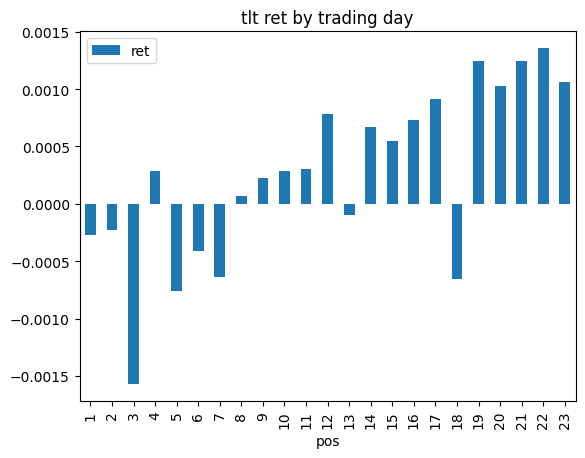

In [2]:
(
    df
    .group_by('pos', maintain_order=True)
    .agg(
        pl.col('ret').mean()
    )
    .to_pandas()
    .plot(
        x='pos',
        y='ret',
        kind='bar',
        title='tlt ret by trading day'
    )
)

<Axes: title={'center': 'tlt ret by trading day (w/o nfp)'}, xlabel='pos'>

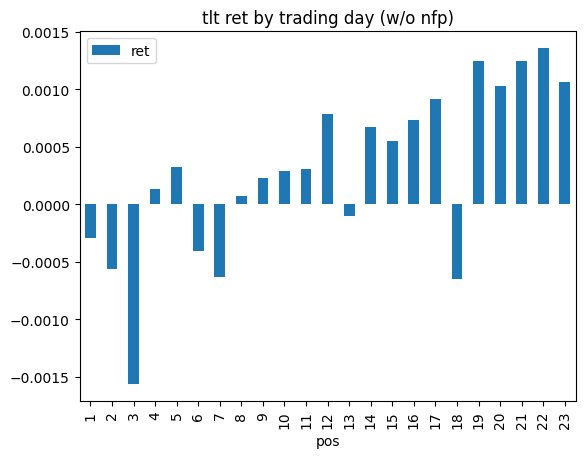

In [3]:
(
    df
    .filter(pl.col('ts').is_in(nfp_releases).not_())
    .group_by('pos', maintain_order=True)
    .agg(
        pl.col('ret').mean()
    )
    .to_pandas()
    .plot(
        x='pos',
        y='ret',
        kind='bar',
        title='tlt ret by trading day (w/o nfp)'
    )
)

In [4]:
month_sel = [
    pl.col("ts").dt.year().alias('year'),
    pl.col("ts").dt.month().alias('month'),
]
eom_period = 5
bom_period = 5

df = (
    pl.read_parquet('output.parquet')
    .with_columns(
        pl.col('symbol').str.to_lowercase()
    )
    .pivot(
        on='symbol',
        index='ts',
        values='close',
    )
    .drop_nulls(['spy','ief'])
    .sort('ts')
)

df = (
    # fill gaps and extend 30d into the future to make day counting work for the current month
    pl.DataFrame({
        "ts": pl.datetime_range(
            start=df["ts"].min(),
            end=df["ts"].max() + dt.timedelta(days=30),
            interval="1d",
            eager=True,
        )
    })
    .join(df, on='ts',how='left')
    .filter(pl.col('ts').is_in(nyse_open))
    .with_columns(
        spy_yday=pl.col('spy').shift(1),
        ief_yday=pl.col('ief').shift(1),
        tlt_yday=pl.col('tlt').shift(1),
    )
    .with_columns(
        # nth trading day in the month
        pos = pl.int_range(1, pl.len() + 1).over(month_sel),
        # number of trading days in this month
        days=pl.len().over(month_sel),

        # mtd return today (rel. last day of the previous month)
        spy_mtd=pl.col("spy") / pl.col("spy_yday").first().over(month_sel) - 1,
        ief_mtd=pl.col("ief") / pl.col("ief_yday").first().over(month_sel) - 1,
    )
    .with_columns(
        # month to date return of the portfolio
        mtd=0.6 * (1 + pl.col("spy_mtd")) + 0.4 * (1 + pl.col("ief_mtd")),
        
        neg_pos=pl.col("days") - pl.col("pos"),      # 0 = last day, 5 = sixth-last
    )
    .with_columns(
        # expected bond buying/selling going into eom
        pressure_bps=(0.4 - 0.4 * (1 + pl.col("ief_mtd")) / pl.col("mtd")) * 1e4,

        # price eom
        tlt_eom=pl.col("tlt").last().over(month_sel),
        spy_eom=pl.col("spy").last().over(month_sel),

        # price bom
        tlt_bom=pl.col("tlt_yday").first().over(month_sel),
        spy_bom=pl.col("spy_yday").first().over(month_sel),
    )
    .with_columns(
        # return until eom
        tlt_fwd_eom=pl.col("tlt_eom") / pl.col("tlt") - 1,
        spy_fwd_eom=pl.col("spy_eom") / pl.col("spy") - 1,

        # return starting next month
        tlt_fwd_bom=pl.col('tlt') / pl.col('tlt_bom') - 1,
        spy_fwd_bom=pl.col('spy') / pl.col('spy_bom') - 1,
    )
    
)

agg = (
    df
    .with_columns(
        pressure_bps=pl.when(pl.col('neg_pos') == eom_period).then(pl.col("pressure_bps")).otherwise(None),
        tlt_eom=pl.when(pl.col('neg_pos') == eom_period).then(pl.col("tlt_fwd_eom")).otherwise(None),
        spy_eom=pl.when(pl.col('neg_pos') == eom_period).then(pl.col("spy_fwd_eom")).otherwise(None),
        tlt_bom=pl.when(pl.col('pos') == bom_period).then(pl.col("tlt_fwd_bom")).otherwise(None),
        spy_bom=pl.when(pl.col('pos') == bom_period).then(pl.col("spy_fwd_bom")).otherwise(None),
    )
    .group_by(month_sel, maintain_order=True)
    .agg(
        pl.col("pressure_bps").drop_nulls().first(),
        pl.col('tlt_eom').drop_nulls().first(),
        pl.col('spy_eom').drop_nulls().first(),
        pl.col('tlt_bom').drop_nulls().first(),
        pl.col('spy_bom').drop_nulls().first(),
    )
    .with_columns(
        # negative = need to sell bonds, positive = need to buy bonds
        bucket=(pl.col('pressure_bps').rank() * 5 / pl.len()).ceil(),
        spy_bom=pl.col('spy_bom').shift(-1),
        tlt_bom=pl.col('tlt_bom').shift(-1),
    )
)

agg

year,month,pressure_bps,tlt_eom,spy_eom,tlt_bom,spy_bom,bucket
i32,i8,f32,f32,f32,f32,f32,f64
2002,7,null,null,null,0.014177,-0.033567,null
2002,8,47.566891,0.013737,-0.029809,0.007184,-0.012203,3.0
2002,9,-286.987732,0.003329,-0.022353,-0.004408,-0.032522,1.0
2002,10,259.494781,0.019513,0.001811,0.016088,0.025305,5.0
2002,11,186.462708,-0.006619,-0.00117,0.011849,-0.020749,5.0
…,…,…,…,…,…,…,…
2026,6,-62.332153,0.002552,0.01798,-0.020232,-0.001835,1.0
2026,7,6.167293,-0.012012,0.010962,0.010254,0.035112,2.0
2026,8,42.394402,-0.000485,0.004689,-0.000061,-0.001421,3.0


<Axes: title={'center': 'ret by 60/40 adj pressure (bond leg, end of month)'}, xlabel='bucket'>

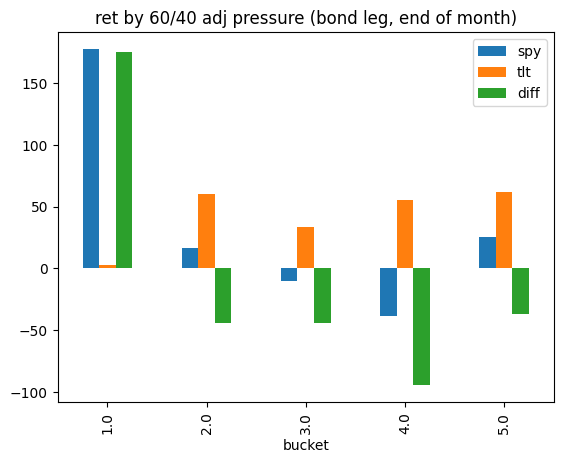

In [5]:
(
    agg
    .drop_nulls()
    .group_by("bucket")
    .agg(
        spy=pl.col("spy_eom").mean() * 1e4,
        tlt=pl.col("tlt_eom").mean() * 1e4,
    )
    .with_columns(diff=pl.col('spy') - pl.col('tlt'))
    .sort("bucket")
).to_pandas().plot(x='bucket',y=['spy','tlt','diff'],kind='bar',title='ret by 60/40 adj pressure (bond leg, end of month)')

<Axes: title={'center': 'ret by 60/40 adj pressure (bond leg, beginning next month)'}, xlabel='bucket'>

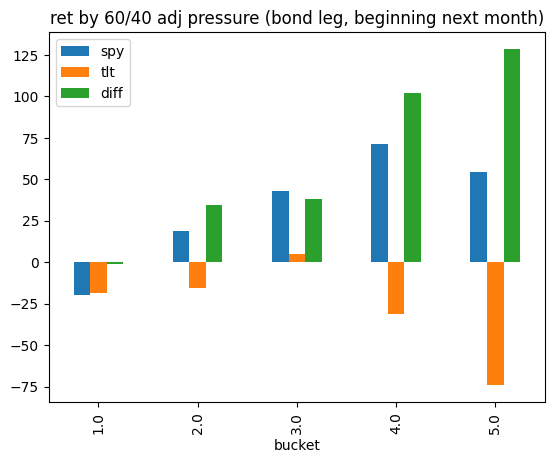

In [6]:
(
    agg
    .drop_nulls()
    .group_by("bucket")
    .agg(
        spy=pl.col("spy_bom").mean() * 1e4,
        tlt=pl.col("tlt_bom").mean() * 1e4,
    )
    .with_columns(diff=pl.col('spy') - pl.col('tlt'))
    .sort("bucket")
).to_pandas().plot(x='bucket',y=['spy','tlt','diff'],kind='bar',title='ret by 60/40 adj pressure (bond leg, beginning next month)')

In [7]:
windows = (
    df
    .with_columns(
        spy_fwd5=pl.col("spy").shift(-5) / pl.col("spy") - 1,
        tlt_fwd5=pl.col("tlt").shift(-5) / pl.col("tlt") - 1,
        month_id=pl.col("ts").dt.year() * 12 + pl.col("ts").dt.month(),
        window=pl.when(pl.col("pos") == 5).then(pl.lit("mid1"))
                 .when(pl.col("pos") == 10).then(pl.lit("mid2"))
                 .when(pl.col("neg_pos") == 5).then(pl.lit("eom"))
                 .otherwise(None),
    )
    .filter(pl.col("window").is_not_null())
    .with_columns(
        is_eom=(pl.col("window") == "eom").cast(pl.Int8),
        pressure_pct=pl.col("pressure_bps") / 100,
        y_spy=pl.col("spy_fwd5") * 1e4,
        y_tlt=pl.col("tlt_fwd5") * 1e4,
        y_diff=(pl.col("spy_fwd5") - pl.col("tlt_fwd5")) * 1e4,
    )
    .drop_nulls(["pressure_pct", "y_spy", "y_tlt"])
)

import statsmodels.formula.api as smf

pdf = windows.to_pandas()
for y in ["y_spy", "y_tlt", "y_diff"]:
    m = smf.ols(f"{y} ~ pressure_pct * is_eom", data=pdf).fit(
        cov_type="cluster", cov_kwds={"groups": pdf["month_id"]}
    )
    print(y)
    print(m.summary().tables[1])

y_spy
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              15.8814     11.638      1.365      0.172      -6.929      38.692
pressure_pct           12.6766     20.038      0.633      0.527     -26.597      51.950
is_eom                 28.5028     18.447      1.545      0.122      -7.653      64.658
pressure_pct:is_eom   -94.3931     38.030     -2.482      0.013    -168.930     -19.857
y_tlt
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               9.3309      8.359      1.116      0.264      -7.052      25.714
pressure_pct           -7.9498     14.369     -0.553      0.580     -36.112      20.213
is_eom                 31.1224     12.269      2.537      0.011       7.076      55.168
pressure_pct:is_eom 

In [36]:
with pl.Config(tbl_cols=-1, tbl_rows=310):
    print(
        df
        .with_columns(
            eom_pos=(
                pl.when(pl.col('pressure_bps') <= -50)
                .then(pl.lit('long spy'))
                .otherwise(pl.lit('long tlt'))
            ),
            bom_pos=(
                pl.when(pl.col('pressure_bps') >= 50)
                    .then(pl.lit('long spy, short tlt'))
                    .otherwise(pl.lit('cash'))),        
        )
        .with_columns(
            instruction=(
                pl.when(pl.col('pressure_bps').is_null())
                    .then(None)
                    .otherwise(
                        pl.when((pl.col('neg_pos') <= eom_period) & (pl.col('neg_pos') > 0))
                            .then('eom_pos')
                            .otherwise(
                                pl.when((pl.col('neg_pos') == 0) | (pl.col('pos') < bom_period))
                                    .then('bom_pos')
                                    .otherwise(pl.lit('cash'))))),
            descision=(
                pl.when(
                    (pl.col('neg_pos') == eom_period) |
                    (pl.col('neg_pos') == 0) |
                    (pl.col('pos') == bom_period))
                    .then(pl.lit('*'))
                    .otherwise(pl.lit(''))
            ),
        )
        .filter(
            (pl.col('ts').dt.year() == dt.datetime.now().year)# &
            #(pl.col('ts') <= dt.datetime.now())
            
            #pl.col('ts').dt.month() == dt.datetime.now().month,
        )
        .select(['ts','pressure_bps','instruction','descision'])
    )

shape: (199, 4)
┌─────────────────────┬──────────────┬─────────────────────┬───────────┐
│ ts                  ┆ pressure_bps ┆ instruction         ┆ descision │
│ ---                 ┆ ---          ┆ ---                 ┆ ---       │
│ datetime[μs]        ┆ f32          ┆ str                 ┆ str       │
╞═════════════════════╪══════════════╪═════════════════════╪═══════════╡
│ 2026-01-02 00:00:00 ┆ 6.391108     ┆ cash                ┆           │
│ 2026-01-05 00:00:00 ┆ 15.081763    ┆ cash                ┆           │
│ 2026-01-06 00:00:00 ┆ 31.02541     ┆ cash                ┆           │
│ 2026-01-07 00:00:00 ┆ 18.82106     ┆ cash                ┆           │
│ 2026-01-08 00:00:00 ┆ 25.788843    ┆ cash                ┆ *         │
│ 2026-01-09 00:00:00 ┆ 38.830341    ┆ cash                ┆           │
│ 2026-01-12 00:00:00 ┆ 45.56358     ┆ cash                ┆           │
│ 2026-01-13 00:00:00 ┆ 37.795303    ┆ cash                ┆           │
│ 2026-01-14 00:00:00 ┆ 21.032393  

cagr 15.51%
vol 11.57%
sharpe 1.34
half-kelly 5.8
maxdd -16.22%


<Axes: xlabel='ts'>

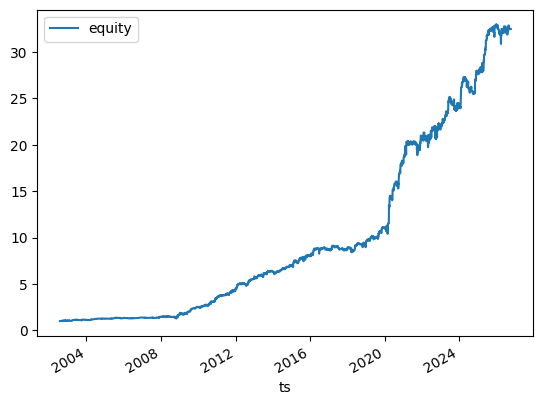

In [69]:
test = (
    df
    .with_columns(
        spy_ret=(pl.col('spy') / pl.col('spy_yday')).log(),
        tlt_ret=(pl.col('tlt') / pl.col('tlt_yday')).log(),
    )
    .with_columns(
        eom_pos=(
            pl.when(pl.col('pressure_bps') <= -50)
            .then('spy_ret')
            .otherwise('tlt_ret')
        ),
        bom_pos=(
            pl.when(pl.col('pressure_bps') >= 50)
                .then(pl.col('spy_ret') - pl.col('tlt_ret'))
                .otherwise(0)
        ),
    )
    .with_columns(
        ret=(
             pl.when(pl.col('neg_pos') <= eom_period)
            .then('eom_pos')
            .otherwise(
                pl.when(pl.col('pos') <= bom_period)
                .then('bom_pos')
                .otherwise(0)
            )
        ),
    )
    .with_columns(
        equity=pl.col('ret').cum_sum().exp(),
    )
    .with_columns(
        maxdd=((pl.col('equity') / pl.col('equity').cum_max()) - 1)
    )
)

import numpy as np

cagr = (np.exp(test['ret'].mean() * 252) - 1)
vol = (test['ret'].exp() - 1).std() * np.sqrt(252)
print(f'cagr {cagr * 100:.2f}%')
print(f'vol {vol * 100:.2f}%')
print(f'sharpe {cagr / vol:.2f}')
print(f'half-kelly {(cagr / vol**2) / 2:.1f}')
print(f'maxdd {test['maxdd'].min() * 100:.2f}%')

test.to_pandas().plot(x='ts',y='equity')

strategy
  years        24.0
  cagr        14.76%
  ann mean    14.41%
  vol         11.37%
  sharpe       1.27
  half-kelly    5.6x
  maxdd      -14.20%
baseline: TLT turn-of-month
  years        24.0
  cagr         7.68%
  ann mean     7.89%
  vol          9.90%
  sharpe       0.80
  half-kelly    4.0x
  maxdd      -19.10%
shape: (3, 6)
┌────────────┬─────┬────────────┬────────────┬──────────┬──────────┐
│ leg        ┆ n   ┆ mean_bps   ┆ std_bps    ┆ t        ┆ win      │
│ ---        ┆ --- ┆ ---        ┆ ---        ┆ ---      ┆ ---      │
│ str        ┆ u32 ┆ f64        ┆ f64        ┆ f64      ┆ f64      │
╞════════════╪═════╪════════════╪════════════╪══════════╪══════════╡
│ bom_spread ┆ 117 ┆ 109.275925 ┆ 327.138348 ┆ 3.61315  ┆ 0.692308 │
│ eom_spy    ┆ 59  ┆ 175.069188 ┆ 357.301033 ┆ 3.763583 ┆ 0.694915 │
│ eom_tlt    ┆ 230 ┆ 51.278149  ┆ 149.94265  ┆ 5.186461 ┆ 0.613043 │
└────────────┴─────┴────────────┴────────────┴──────────┴──────────┘


<Axes: xlabel='ts'>

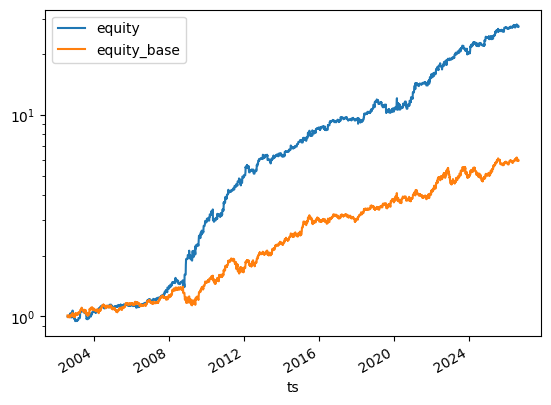

In [71]:
import numpy as np
import polars as pl

EOM_PERIOD = 5          # trading days in the month-end leg
BOM_PERIOD = 5          # trading days in the reversal leg
SELL_THRESH = -50       # bps: strong expected bond selling -> long SPY into month-end
BUY_THRESH = 50         # bps: strong expected bond buying  -> short TLT / long SPY after month-end
SPREAD_SCALE = 1.0      # 1.0 = 100% long SPY + 100% short TLT (article); 0.5 for a cash account
COST_BPS = 1.0          # per unit of turnover (one side)

month_sel = [
    pl.col("ts").dt.year().alias("year"),
    pl.col("ts").dt.month().alias("month"),
]

# ---------------------------------------------------------------- daily frame
daily = (
    pl.read_parquet("output.parquet")
    .with_columns(pl.col("symbol").str.to_lowercase())
    .pivot(on="symbol", index="ts", values="close")     # adjusted closes
    .drop_nulls(["spy", "ief", "tlt"])
    .sort("ts")
    .filter(pl.col("ts").is_in(nyse_open))
    .with_columns(month_sel)
    .with_columns(
        spy_yday=pl.col("spy").shift(1),
        ief_yday=pl.col("ief").shift(1),
        tlt_yday=pl.col("tlt").shift(1),
    )
    .with_columns(
        pos=pl.int_range(1, pl.len() + 1).over(month_sel),
        days=pl.len().over(month_sel),
        # month-to-date returns measured from the previous month-end close
        spy_mtd=pl.col("spy") / pl.col("spy_yday").first().over(month_sel) - 1,
        ief_mtd=pl.col("ief") / pl.col("ief_yday").first().over(month_sel) - 1,
        # simple daily returns (adjusted closes -> dividends included)
        spy_ret=pl.col("spy") / pl.col("spy_yday") - 1,
        tlt_ret=pl.col("tlt") / pl.col("tlt_yday") - 1,
    )
    .with_columns(
        neg_pos=pl.col("days") - pl.col("pos"),          # 0 = last day, 5 = sixth-last
        port=0.6 * (1 + pl.col("spy_mtd")) + 0.4 * (1 + pl.col("ief_mtd")),
    )
    .with_columns(
        # bond trade a 60/40 SPY/IEF investor needs, bps of portfolio value
        pressure_bps=(0.4 - 0.4 * (1 + pl.col("ief_mtd")) / pl.col("port")) * 1e4,
    )
)

# drop the incomplete last month (its "month-end" is not a month-end)
last_year, last_month = daily.select(pl.col("year").last(), pl.col("month").last()).row(0)
daily = daily.filter(~((pl.col("year") == last_year) & (pl.col("month") == last_month)))
daily = daily.filter(pl.col("spy_ret").is_not_null() & pl.col("tlt_ret").is_not_null())

# --------------------------------------------------------------- signal frame
sig = (
    daily.group_by(month_sel, maintain_order=True)
    .agg(
        sig=pl.col("pressure_bps").filter(pl.col("neg_pos") == EOM_PERIOD).first(),
        month_id=(pl.col("year") * 12 + pl.col("month")).first(),
    )
    .with_columns(sig_prev=pl.col("sig").shift(1))
)
assert (sig["month_id"].diff().drop_nulls() == 1).all(), "gap in months: shift(1) misaligned"

# ------------------------------------------------------------------ backtest
# convention: w_* are the weights that earn the return of that row,
# i.e. set at the previous close. cost is charged on the day the weight changes.
test = (
    daily.join(sig.drop("month_id"), on=["year", "month"], how="left")
    .with_columns(
        in_eom=pl.col("neg_pos") < EOM_PERIOD,   # returns of the last 5 days
        in_bom=pl.col("pos") <= BOM_PERIOD,      # returns of the first 5 days
    )
    .with_columns(
        leg=pl.when(pl.col("in_eom") & (pl.col("sig") <= SELL_THRESH)).then(pl.lit("eom_spy"))
             .when(pl.col("in_eom") & (pl.col("sig") > SELL_THRESH)).then(pl.lit("eom_tlt"))
             .when(pl.col("in_bom") & (pl.col("sig_prev") >= BUY_THRESH)).then(pl.lit("bom_spread"))
             .otherwise(pl.lit("flat")),
    )
    .with_columns(
        w_spy=pl.when(pl.col("leg") == "eom_spy").then(1.0)
               .when(pl.col("leg") == "bom_spread").then(SPREAD_SCALE)
               .otherwise(0.0),
        w_tlt=pl.when(pl.col("leg") == "eom_tlt").then(1.0)
               .when(pl.col("leg") == "bom_spread").then(-SPREAD_SCALE)
               .otherwise(0.0),
        # baseline (green line): long TLT into month-end, short TLT after
        w_tlt_base=pl.when(pl.col("in_eom")).then(1.0)
                    .when(pl.col("in_bom")).then(-1.0)
                    .otherwise(0.0),
    )
    .with_columns(
        turnover=(pl.col("w_spy") - pl.col("w_spy").shift(1, fill_value=0.0)).abs()
               + (pl.col("w_tlt") - pl.col("w_tlt").shift(1, fill_value=0.0)).abs(),
        turnover_base=(pl.col("w_tlt_base") - pl.col("w_tlt_base").shift(1, fill_value=0.0)).abs(),
    )
    .with_columns(
        ret=pl.col("w_spy") * pl.col("spy_ret")
          + pl.col("w_tlt") * pl.col("tlt_ret")
          - pl.col("turnover") * COST_BPS * 1e-4,
        ret_base=pl.col("w_tlt_base") * pl.col("tlt_ret")
               - pl.col("turnover_base") * COST_BPS * 1e-4,
    )
    .with_columns(
        equity=(1 + pl.col("ret")).cum_prod(),
        equity_base=(1 + pl.col("ret_base")).cum_prod(),
    )
    .with_columns(
        dd=pl.col("equity") / pl.col("equity").cum_max() - 1,
        dd_base=pl.col("equity_base") / pl.col("equity_base").cum_max() - 1,
    )
)

# ---------------------------------------------------------------- statistics
def stats(t: pl.DataFrame, ret: str, eq: str, dd: str, name: str) -> None:
    r = t[ret].to_numpy()
    years = len(r) / 252
    ann_mean = r.mean() * 252
    vol = r.std(ddof=1) * np.sqrt(252)          # zeros on flat days are part of the series
    cagr = t[eq][-1] ** (1 / years) - 1
    print(f"{name}")
    print(f"  years      {years:6.1f}")
    print(f"  cagr       {cagr*100:6.2f}%")
    print(f"  ann mean   {ann_mean*100:6.2f}%")
    print(f"  vol        {vol*100:6.2f}%")
    print(f"  sharpe     {ann_mean/vol:6.2f}")
    print(f"  half-kelly {ann_mean/vol**2/2:6.1f}x")
    print(f"  maxdd      {t[dd].min()*100:6.2f}%")

stats(test, "ret", "equity", "dd", "strategy")
stats(test, "ret_base", "equity_base", "dd_base", "baseline: TLT turn-of-month")

# per-cell table: one row per (month, leg) trade
cells = (
    test.filter(pl.col("leg") != "flat")
    .group_by(["year", "month", "leg"], maintain_order=True)
    .agg(trade=(1 + pl.col("ret")).product() - 1)
    .group_by("leg")
    .agg(
        n=pl.len(),
        mean_bps=pl.col("trade").mean() * 1e4,
        std_bps=pl.col("trade").std() * 1e4,
        t=pl.col("trade").mean() / pl.col("trade").std() * pl.len().sqrt(),
        win=(pl.col("trade") > 0).mean(),
    )
    .sort("leg")
)
print(cells)

test.to_pandas().plot(x="ts", y=["equity", "equity_base"], logy=True)